In [2]:
import os
import sys
import re

project_root = "/root/work/tenset"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build:" + os.environ.get("LD_LIBRARY_PATH", "")


sys.path.append("/root/work/tenset/scripts")
from unfolding.util_modules.util_manager import seed_everything
seed_everything(42)

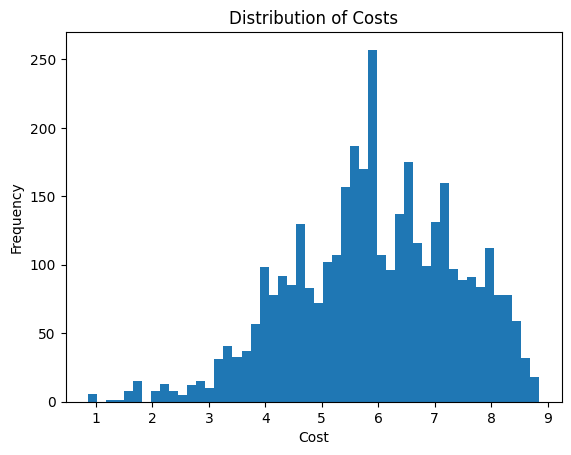

In [3]:
import numpy as np
import torch


sys.path.append("/root/work/tenset/scripts")
from unfolding.extract_i_vectors import process_only_diff

json_diffs = process_only_diff("/root/work/tenset/dataset/measure_records_tenset/k80/([0bcc0b358b2b1d00bc591087e839592d,1,35,35,64,4,4,96,64,1,1,1,96,1,35,35,96],cuda).json", limit=None)
raw_input = json_diffs["diff_values"]
input_data = np.log2(raw_input+1e-8)
cost = -np.log(json_diffs["cost"])


from unfolding.util_modules.plot.cost_dist import plot_cost_distribution

plot_cost_distribution(cost)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

input_data = np.log(json_diffs["diff_values"]+1e-8)

scaler = StandardScaler()
input_data_scaled = scaler.fit_transform(input_data)

X_train, X_val, y_train, y_val = train_test_split(
    input_data_scaled, cost, test_size=0.5, random_state=42
)

# input_data, mean, std = transform_schedule(json_diffs["diff_values"])


In [5]:
def config_filename(first, config, type="png"):
    os.makedirs(os.path.dirname(first), exist_ok=True)
    filename = f"{first}"
    for k, v in config.items():
        if v is not None or v > 0:
            key_name = k.replace("lambda_", "")
            if len(key_name) > 3:
                key_name = key_name[:3]
            filename += f"_{key_name}{v}"

    filename += f".{type}"
    return filename

In [ ]:
from torch.utils.data import DataLoader
sys.path.append("/root/work/tenset/scripts")
from unfolding.torch.models.vae_cost import VAE_cost
import pandas as pd

from sklearn.metrics import r2_score
import torch
sys.path.append("/root/work/tenset/scripts")
from unfolding.torch.dataset import X_y_regression_Dataset
from unfolding.util_modules.loss import reconstruction_loss, kld_loss, infonce_loss, reg_loss, pair_loss, smooth_loss


import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


train_dataset = X_y_regression_Dataset(X_train, y_train)
val_dataset   = X_y_regression_Dataset(X_val,   y_val)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=512, shuffle=False)



input_dim = X_train.shape[-1]
latent_dim = 64
hidden_dim = 256

hyperparams = {
    'epochs': [100, 1000, 2000],
    'lr': [5e-5, 1e-4],
    "lambda_recon": [1.0],
    "lambda_kld": [0.0, 0.01, 0.1],
    "lambda_reg": [0.1, 0.01],
    "lambda_pair": [0.0, 0.1, 0.5, 1.0],
    "lambda_smooth": [0.0, 0.01, 0.1],
    "lambda_infonce": [0.0, 0.01, 0.1, 0.2],
}

results_interpolation_geo = []
results_interpolation_search = []
results_train = []


for idx, config_tup in enumerate(itertools.product(*hyperparams.values())):
    print(f"=== Hyperparameter set {idx+1} / {np.prod([len(v) for v in hyperparams.values()])} ===")

    # config 딕셔너리 생성
    config = dict(zip(hyperparams.keys(), config_tup))
    print("Training with config:", config)

    vae = VAE_cost(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=config['lr'])


    for epoch in range(1, config['epochs'] + 1):
        # 여기서는 그냥 전체를 한 번에 돌린다고 가정 (실제로는 DataLoader로 배치 쪼개기)
        vae.train()
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)  # (N, D)
            y_batch = y_batch.to(device)  # (N,)

            # x_cont, _, _ = transform_schedule(x_batch, mean=mean, std=std)  # (N, 2D)

            x_recon, mu, logvar, z, cost_pred = vae(x_batch)
            loss = 0

            recon_loss = config['lambda_recon'] * reconstruction_loss(x_recon, x_batch)
            kl = config['lambda_kld'] * kld_loss(mu, logvar)
            cost_loss = config['lambda_reg'] * reg_loss(cost_pred, y_batch.view(-1))

            loss += recon_loss
            loss += kl
            loss += cost_loss

            loss += config['lambda_pair'] * pair_loss(cost_pred, y_batch.view(-1))
            loss += config['lambda_smooth'] * smooth_loss(vae, z, noise_std=0.01)
            loss += config['lambda_infonce'] * infonce_loss(z, y_batch.view(-1))


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        vae.eval()

        cost_preds = []
        cost_trues = []
        x_batch_all = []
        x_recon_all = []

        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            x_recon, mu, logvar, z, cost_pred = vae(x_batch)

            val_recon_loss = config['lambda_recon'] * reconstruction_loss(x_recon, x_batch)
            val_kl = config['lambda_kld'] * kld_loss(mu, logvar)
            val_cost_loss = config['lambda_reg'] * reg_loss(cost_pred, y_batch.view(-1))
            val_total_loss = val_recon_loss + val_kl + 0.1* val_cost_loss


            cost_preds.append(cost_pred.detach().cpu())
            cost_trues.append(y_batch.view(-1).detach().cpu())
            x_batch_all.append(x_batch.detach().cpu())
            x_recon_all.append(x_recon.detach().cpu())

        if epoch % 100 == 0:
            print(f"epoch {epoch}: loss={loss.item():.4f}, recon={recon_loss.item():.4f}, kl={kl.item():.4f}, cost={cost_loss.item():.4f}")
            print(f"epoch {epoch}: val loss={val_total_loss.item():.4f}, val recon={val_recon_loss.item():.4f}, val kl={val_kl.item():.4f}, val cost={val_cost_loss.item():.4f}")
            
            cost_trues = torch.cat(cost_trues).numpy()
            cost_preds = torch.cat(cost_preds).numpy()
            val_recon_r2 = r2_score(torch.cat(x_batch_all).numpy(), torch.cat(x_recon_all).numpy())
            val_reg_r2 = r2_score(cost_trues, cost_preds)
            print(f"Validation Cost R2: {val_recon_r2:.4f}, Reconstruction R2: {val_reg_r2:.4f}")
    from unfolding.util_modules.plot.interpolation_geometry import plot_interpolation_geometry
    from unfolding.util_modules.plot.interpolation_search import plot_interpolation_search
    from unfolding.util_modules.plot.latent_cost_geometry import plot_latent_cost_geometry
    inter_geometry_summary = plot_interpolation_geometry(vae, X_train, y_train, X_val, y_val, device, type="latent", only_summary=True) # inter_geometry_summary : dict
    inter_search_summary = plot_interpolation_search(vae, X_train, y_train, X_val, y_val, device, type="latent", only_summary=True) # inter_search_summary : dict

    results_interpolation_geo.append({
        "config": config,
        "summary": inter_geometry_summary,
    })
    results_interpolation_search.append({
        "config": config,
        "summary": inter_search_summary,
    })
    results_train.append({
        "config": config,
        "val_recon_r2": val_recon_r2,
        "val_reg_r2": val_reg_r2,
    })

    # pandas DataFrame으로 저장
    df_geo = pd.DataFrame([{**r["config"], **r["summary"]} for r in results_interpolation_geo])
    df_search = pd.DataFrame([{**r["config"], **r["summary"]} for r in results_interpolation_search])
    df_train = pd.DataFrame([{**r["config"], "val_recon_r2": r["val_recon_r2"], "val_reg_r2": r["val_reg_r2"]} for r in results_train])
    df_geo.to_csv("results/interpolation_geometry.csv", index=False)
    df_search.to_csv("results/interpolation_search.csv", index=False)
    df_train.to_csv("results/train.csv", index=False)
    

    with torch.no_grad():
        x_recon, mu, logvar, z, cost_pred = vae(torch.tensor(X_val).float().to(device))
    geometry_fig_name_pca = config_filename("results_plot/pca/geo", config, type="png")
    plot_latent_cost_geometry(Z=z.detach().cpu().numpy(), cost=y_val, method="pca", seed=0, save_path=geometry_fig_name_pca, show=False)
    geometry_fig_name_umap = config_filename("results_plot/umap/geo", config, type="png")
    plot_latent_cost_geometry(Z=z.detach().cpu().numpy(), cost=y_val, method="umap", seed=0, save_path=geometry_fig_name_umap, show=False)

=== Hyperparameter set 1 / 1728 ===
Training with config: {'epochs': 100, 'lr': 5e-05, 'lambda_recon': 1.0, 'lambda_kld': 0.0, 'lambda_reg': 0.1, 'lambda_pair': 0.0, 'lambda_smooth': 0.0, 'lambda_infonce': 0.0}
epoch 100: loss=1.0595, recon=0.9805, kl=0.0000, cost=0.0790
epoch 100: val loss=0.9945, val recon=0.9850, val kl=0.0000, val cost=0.0948
Validation Cost R2: 0.0097, Reconstruction R2: 0.5684
=== Summary ===
[warn] train good seed가 184개뿐이라 전부 사용함.


2026-01-08 19:57:29.257510: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-08 19:57:29.288291: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 19:57:29.779151: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: 

=== Hyperparameter set 2 / 1728 ===
Training with config: {'epochs': 100, 'lr': 5e-05, 'lambda_recon': 1.0, 'lambda_kld': 0.0, 'lambda_reg': 0.1, 'lambda_pair': 0.0, 'lambda_smooth': 0.0, 'lambda_infonce': 0.01}
epoch 100: loss=1.0780, recon=0.9847, kl=0.0000, cost=0.0844
epoch 100: val loss=0.9974, val recon=0.9879, val kl=0.0000, val cost=0.0947
Validation Cost R2: 0.0077, Reconstruction R2: 0.5878
[warn] pairs 부족: 158/200. dist quantile을 낮춰라(예: 0.6).
=== Summary ===
[warn] train good seed가 184개뿐이라 전부 사용함.


/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [10]:
results_interpolation_geo[0]['summary']['good_good']

{'num_pairs': 200.0,
 'tv_mean': 2.0213,
 'tv_median': 1.8159,
 'spearman_mean': 0.0343,
 'spearman_median': 0.0136,
 'unique_mean': 5.98,
 'unique_median': 6.0}

In [76]:
sys.path.append("/root/work/tenset/scripts")
from unfolding.util_modules.plot.interpolation_search import plot_interpolation_search
# reload import
import importlib
importlib.reload(sys.modules["unfolding.util_modules.plot.interpolation_search"])
a = plot_interpolation_search(vae, X_train, y_train, X_val, y_val, device, type="input", only_summary=True)

[warn] train good seed가 184개뿐이라 전부 사용함.


[warn] pairs 부족: 175/200. dist quantile을 낮춰라(예: 0.6).
=== Summary ===
good_good {'num_pairs': 175.0, 'tv_mean': 1.6367, 'tv_median': 1.3205, 'spearman_mean': -0.086, 'spearman_median': -0.2091, 'unique_mean': 6.32, 'unique_median': 6.0}
good_bad {'num_pairs': 200.0, 'tv_mean': 4.4342, 'tv_median': 4.4015, 'spearman_mean': -0.9689, 'spearman_median': -0.9818, 'unique_mean': 8.615, 'unique_median': 9.0, 'mono_viol_mean': 0.335, 'mono_viol_median': 0.0}
bad_bad {'num_pairs': 200.0, 'tv_mean': 1.6558, 'tv_median': 1.8472, 'spearman_mean': 0.0906, 'spearman_median': 0.4682, 'unique_mean': 6.245, 'unique_median': 6.0}


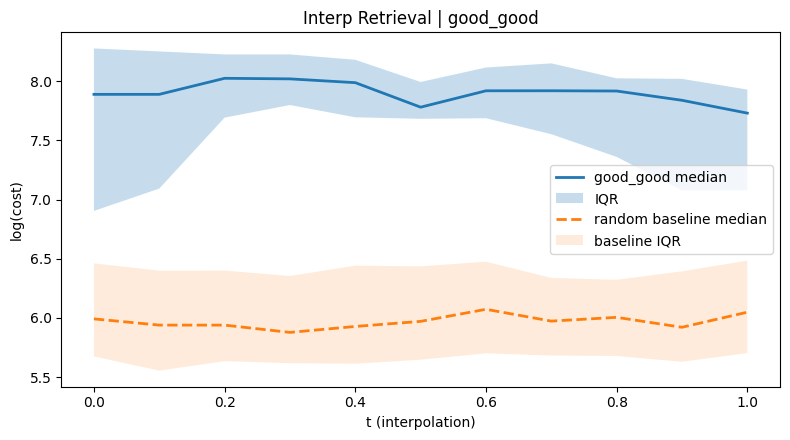

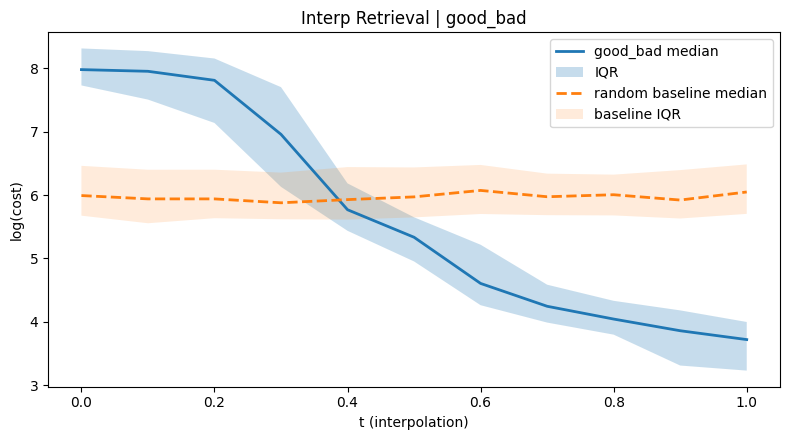

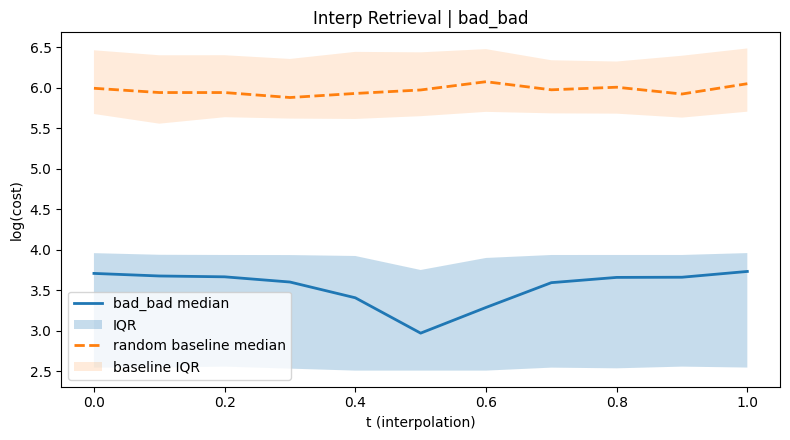

In [35]:
sys.path.append("/root/work/tenset/scripts")
from unfolding.util_modules.plot.interpolation_geometry import plot_interpolation_geometry
# reload import
import importlib
importlib.reload(sys.modules["unfolding.util_modules.plot.interpolation_geometry"])
plot_interpolation_geometry(vae, X_train, y_train, X_val, y_val, device, type="latent")


In [17]:
z.shape

torch.Size([303, 64])

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


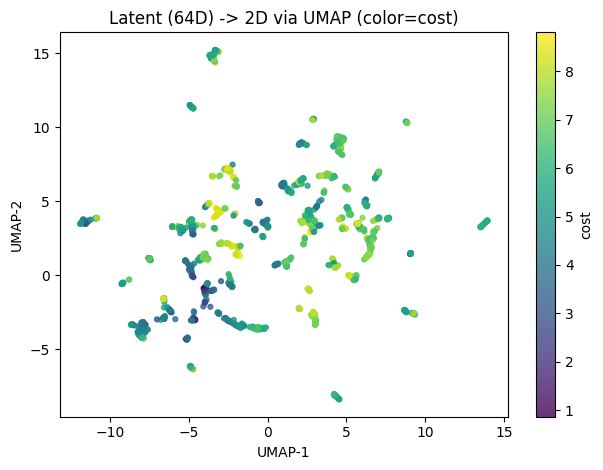

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


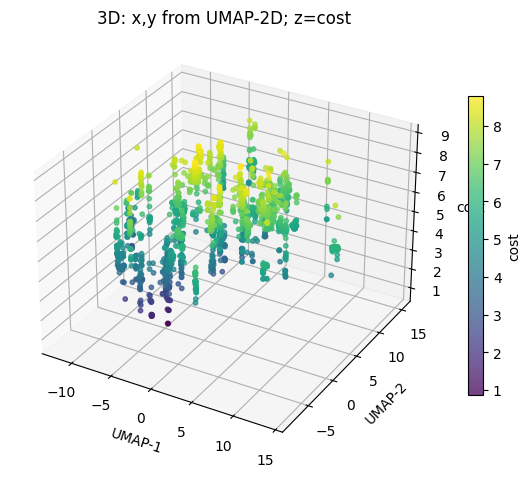

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


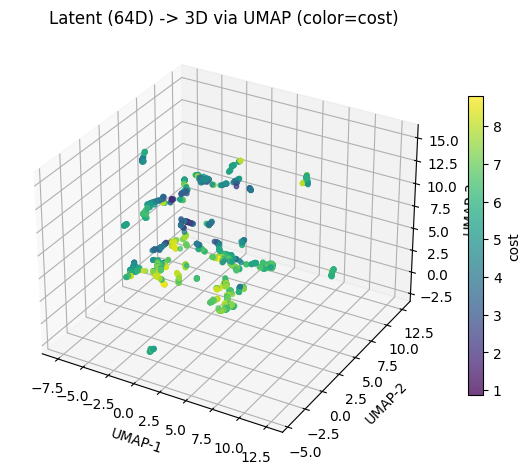

In [57]:
sys.path.append("/root/work/tenset/scripts")
from unfolding.util_modules.plot.latent_cost_geometry import plot_latent_cost_geometry
import importlib
importlib.reload(sys.modules["unfolding.util_modules.plot.latent_cost_geometry"])

vae.eval()
with torch.no_grad():
    x_recon, mu, logvar, z, cost_pred = vae(torch.tensor(X_val).float().to(device))
plot_latent_cost_geometry(Z=z.detach().cpu().numpy(), cost=y_val, method="umap", seed=42)
# plot_latent_cost_geometry(Z=X_val, cost=y_val, method="umap", seed=42)

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


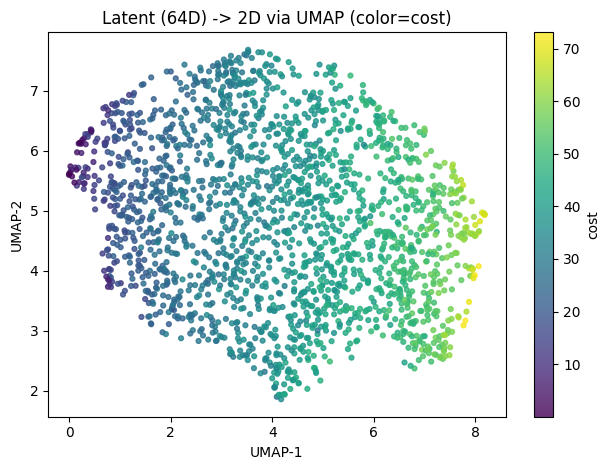

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


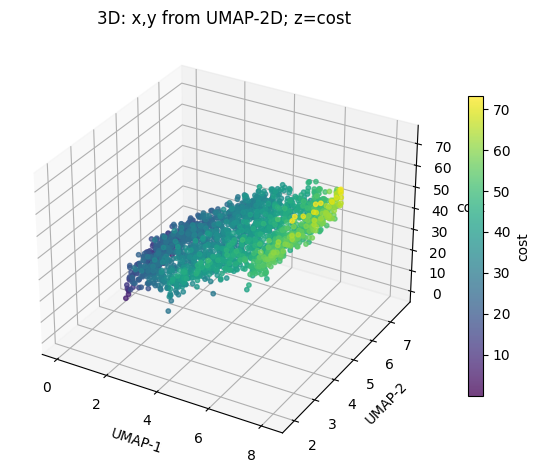

/root/work/tenset/.venv/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


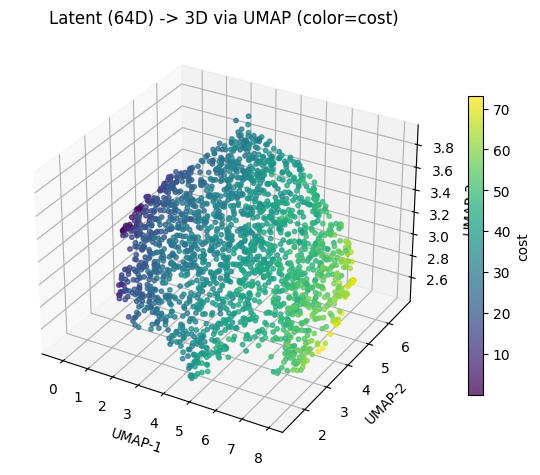

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def make_ideal_latent_pca_visible(
    N=2000,
    D=64,
    signal_std=6.0,     # 핵심: 신호 분산을 크게
    noise_std=1.0,      # 노이즈는 상대적으로 작게
    cost_noise_std=0.3, # cost 자체 노이즈
    seed=0,
):
    """
    목표:
      - latent에 'cost slope' 방향을 심고,
      - 그 방향 분산을 크게 해서 PCA가 PC1으로 거의 확실히 잡게 함.
      - 결과적으로 PCA-1 방향으로 cost가 단조 그라데이션을 보임.
    """
    rng = np.random.default_rng(seed)

    # 1) D차원에서 서로 직교하는 두 개의 "특별한" 방향 u, v 생성
    A = rng.normal(size=(D, D))
    Q, _ = np.linalg.qr(A)   # Q: orthonormal basis
    u = Q[:, 0]              # cost slope direction (강한 신호)
    v = Q[:, 1]              # 보조 방향 (약한 신호)

    # 2) 핵심 2D 좌표 (a,b)를 크게 뿌려서 PCA가 잡기 쉽게 함
    a = rng.normal(scale=signal_std, size=N)
    b = rng.normal(scale=signal_std * 0.7, size=N)

    # 3) latent 구성: Z = a*u + b*v + noise
    Z = np.outer(a, u) + np.outer(b, v) + rng.normal(scale=noise_std, size=(N, D))

    # 4) cost는 (주로 a)에 단조 의존 + 약간 b + 노이즈
    cost = 2.0 * a + 0.3 * b + rng.normal(scale=cost_noise_std, size=N)

    # 낮을수록 좋다고 가정한다면, 그냥 cost를 그대로 써도 되고
    # 시각화를 위해 양수로 만들고 싶으면 아래처럼 shift만 (정렬은 안 깨짐)
    cost = cost - cost.min() + 1e-3

    return Z, cost

def quick_pca_plots(Z, cost):
    cost = np.asarray(cost).reshape(-1)
    pca2 = PCA(n_components=2).fit_transform(Z)
    pca3 = PCA(n_components=3).fit_transform(Z)

    # 2D (color=cost)
    plt.figure()
    sc = plt.scatter(pca2[:,0], pca2[:,1], c=cost, s=10, alpha=0.8)
    plt.colorbar(sc, label="cost")
    plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
    plt.title("Ideal synthetic: PCA-2D (color=cost)")
    plt.tight_layout()
    plt.show()

    # 3D height: x,y from PCA2; z=cost
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(pca2[:,0], pca2[:,1], cost, c=cost, s=8, alpha=0.75)
    fig.colorbar(sc, ax=ax, label="cost", shrink=0.7)
    ax.set_xlabel("PCA-1"); ax.set_ylabel("PCA-2"); ax.set_zlabel("cost")
    ax.set_title("Ideal synthetic: 3D (x,y=PCA2; z=cost)")
    plt.tight_layout()
    plt.show()

    # sanity: PC1과 cost 상관 확인
    pc1 = pca2[:,0]
    pearson = np.corrcoef(pc1, cost)[0,1]
    # spearman (간단히 rank로 근사)
    r1 = pc1.argsort().argsort()
    r2 = cost.argsort().argsort()
    spearman = np.corrcoef(r1, r2)[0,1]
    print(f"corr(PC1, cost): pearson={pearson:.3f}, spearman={spearman:.3f}")


z_ex, cost_ex = make_ideal_latent_pca_visible()
plot_latent_cost_graph(Z=z_ex, cost=cost_ex, method="umap", seed=42)